In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from libs.parser import parse_log_file

# Trilinos Solver Benchmark

## Trilinos Implementation Summary

- **Krylov solver**: GMRES (Belos `BlockGmresSolMgr`)
- **Preconditioner**: Smoothed Aggregation AMG (MueLu), Chebyshev smoother
- **Parallelism**: MPI via Tpetra, with DOF-aligned row partitioning for elasticity

### Why GMRES (Generalized Minimal RESidual) instead of CG?

CG requires the preconditioner to be symmetric positive definite (SPD). MueLu's SA-AMG V-cycle loses its SPD property on multiple MPI ranks because `UncoupledAggregation` aggregates each rank's local rows independently — more ranks means more fragmented aggregates and a poorer coarse grid that can over-correct in certain directions. In testing, CG crashed on np=4 with "non-positive p^H\*A\*p". GMRES does not require an SPD preconditioner and works reliably at all process counts with minimal overhead (~4% slower than CG at the same iteration count).

Hypre's BoomerAMG can use CG because it uses a fundamentally different AMG pipeline (HMIS coarsening, Extended+i interpolation, L1-Gauss-Seidel smoother) that is engineered to preserve the SPD property in parallel.

### Why Chebyshev smoother?

MueLu's default Symmetric Gauss-Seidel is applied locally per process and is not truly symmetric in parallel, which degrades GMRES convergence (1000 iters, did not converge on np=4). Chebyshev is a polynomial smoother that is inherently parallel-safe and symmetric regardless of process count. It is also MueLu's recommended smoother for SA-AMG elasticity problems.

### Solvers compared

| Solver | Type | 
|--------|------|
| **Trilinos** | Iterative (GMRES + SA-AMG) |
| **Hypre** | Iterative (PCG + BoomerAMG) | 
| **AMGCL** | Iterative (CG + SA-AMG) | 
| **Eigen::PardisoLDLT** | Direct (LDL^T) | 

In [2]:
data_dir = "/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together"

solver_map = {
    "Pardiso": "Eigen::PardisoLDLT",
    "AMGCL": "AMGCL",
    "Hypre": "Hypre",
    "Trilinos": "Trilinos",
}

data_all = []
for current_dir in sorted(os.listdir(data_dir)):
    full_dir = os.path.join(data_dir, current_dir)
    if not os.path.isdir(full_dir):
        continue
    # Directory names: old_data_1, old_data_8, golf_ball_4, etc.
    num_threads = int(current_dir.split("_")[-1])

    for fname in sorted(os.listdir(full_dir)):
        if not fname.endswith(".log"):
            continue
        solver = None
        for key, val in solver_map.items():
            if key in fname:
                solver = val
                break
        if solver is None:
            continue

        log_path = os.path.join(full_dir, fname)
        try:
            data = parse_log_file(log_path, solver)
        except Exception as e:
            print(f"Error parsing {log_path}: {e}")
            continue
        for entry in data:
            entry["num_threads"] = num_threads
        data_all.extend(data)

print(f"Total entries: {len(data_all)}")

Error parsing /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_1/Trilinos_2D-arch.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_1/Trilinos_2D-arch.log
Error parsing /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_1/Trilinos_2D-card-house.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_1/Trilinos_2D-card-house.log
Error parsing /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_1/Trilinos_2D-cliff-edges.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_1/Trilinos_

Error parsing /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_2/Trilinos_2D-arch.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_2/Trilinos_2D-arch.log
Error parsing /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_2/Trilinos_2D-card-house.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_2/Trilinos_2D-card-house.log
Error parsing /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_2/Trilinos_2D-cliff-edges.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-11/all_together/old_data_2/Trilinos_

In [3]:
grouped_data = []
for entry in data_all:
    this_data = {
        "solver_name": entry["solver"],
        "mat_sz": entry["mat_sz"],
        "elapse_time": entry["elapse_time"],
        "num_iterations": entry.get("num_iterations", 0),
        "num_threads": entry["num_threads"],
    }
    grouped_data.append(this_data)

df = pd.DataFrame(grouped_data)
solver_list = sorted(df["solver_name"].unique())
thread_values = sorted(df["num_threads"].unique())
print("Solvers:", solver_list)
print("Thread values:", thread_values)
print("Shape:", df.shape)

Solvers: ['AMGCL', 'Eigen::PardisoLDLT', 'Hypre', 'Trilinos']
Thread values: [1, 2, 4, 8]
Shape: (1234, 5)


## Plot 1: All solvers compared at each #thread
For each thread count (1, 2, 4, 8), one figure showing elapse_time vs mat_size for all solvers.

/tmp/ipykernel_2585438/158918507.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_solvers = cm.get_cmap("tab10", len(solver_list))


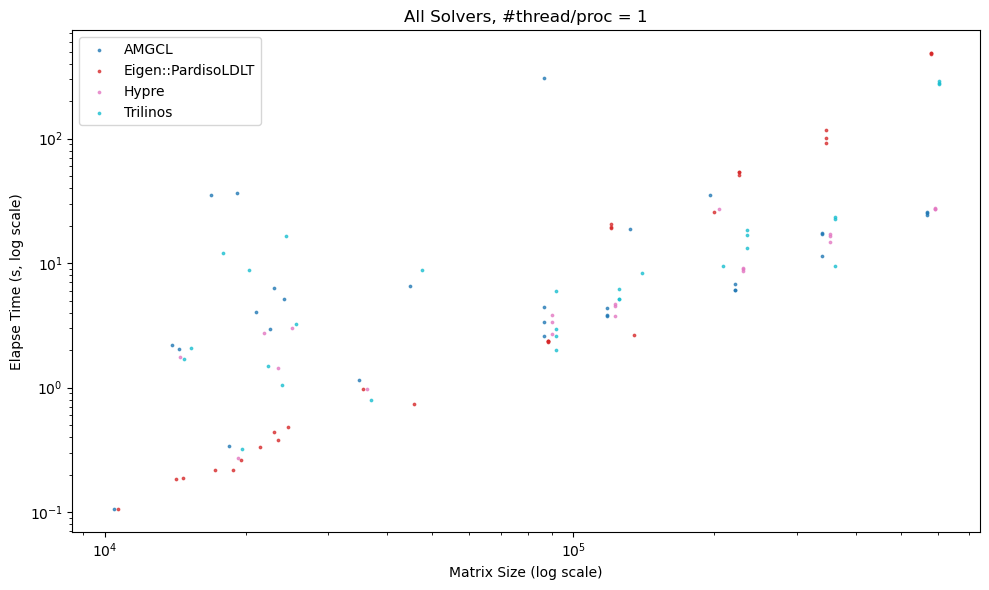

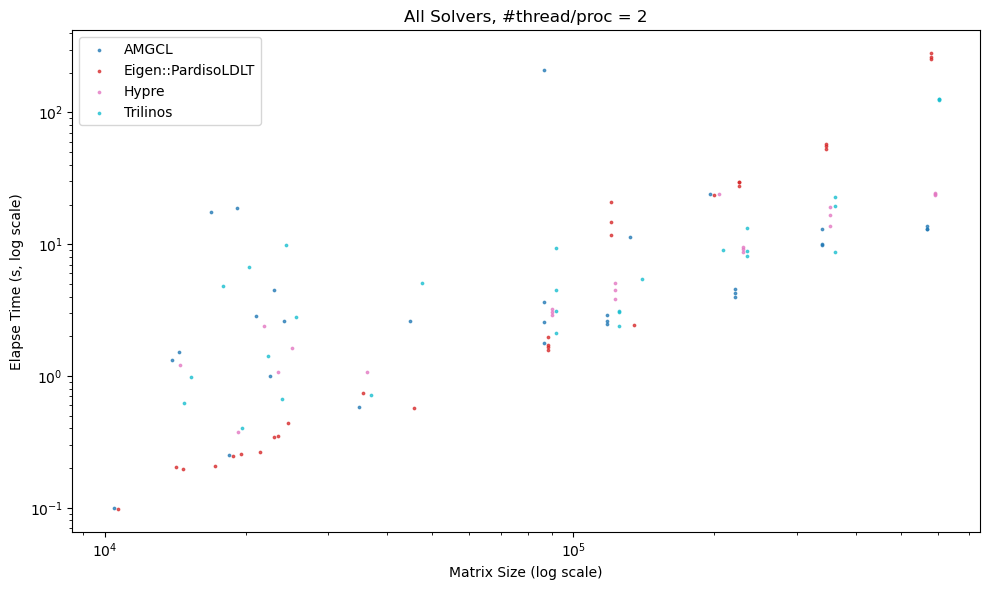

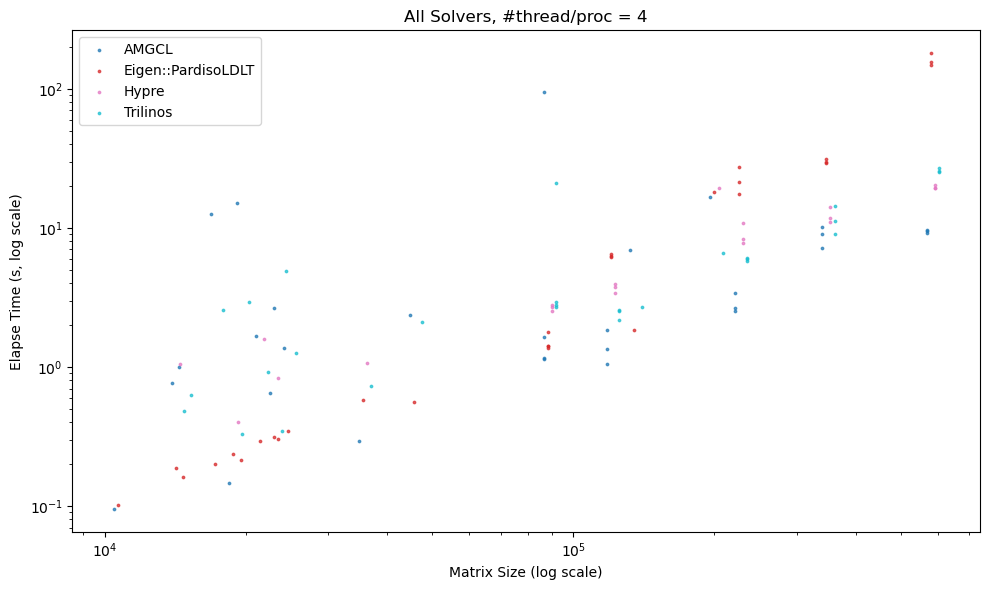

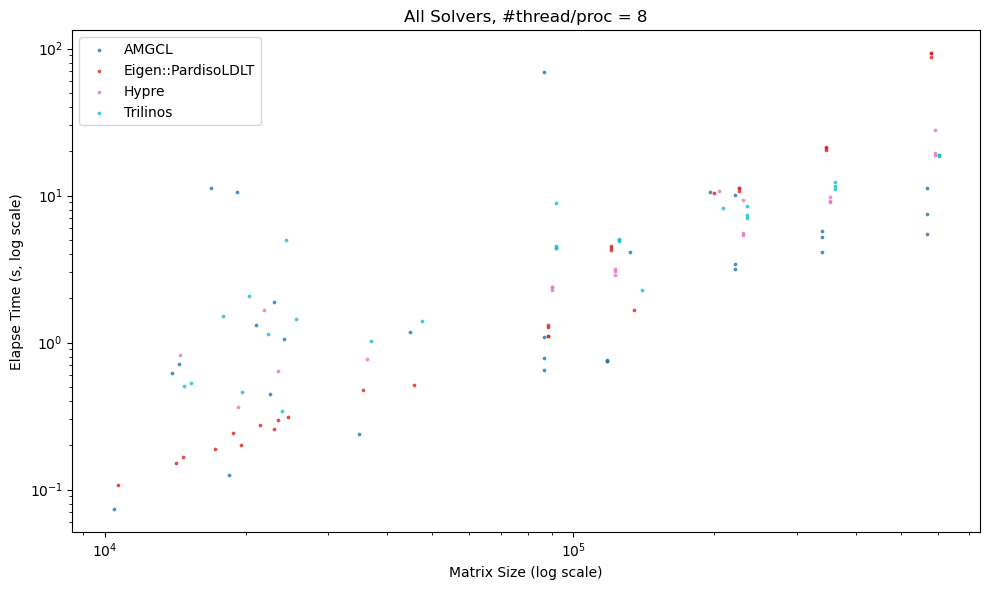

In [4]:
cmap_solvers = cm.get_cmap("tab10", len(solver_list))

for nt in thread_values:
    df_t = df[(df["num_threads"] == nt) & (df["mat_sz"] >= 1e4)]
    if df_t.empty:
        continue

    plt.figure(figsize=(10, 6))
    offset = 1
    for idx, (solver, sdf) in enumerate(df_t.groupby("solver_name")):
        color = cmap_solvers(idx)
        plt.scatter(sdf["mat_sz"] * offset, sdf["elapse_time"],
                    s=3, alpha=0.7, color=color, label=solver)
        offset *= 1.02

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Matrix Size (log scale)")
    plt.ylabel("Elapse Time (s, log scale)")
    plt.title(f"All Solvers, #thread/proc = {nt}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Plot 2: Each solver across different #threads
For each solver, one figure showing elapse_time vs mat_size at #thread = 1, 2, 4, 8.

/tmp/ipykernel_2585438/969576183.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_threads = cm.get_cmap("Set2", len(thread_values))


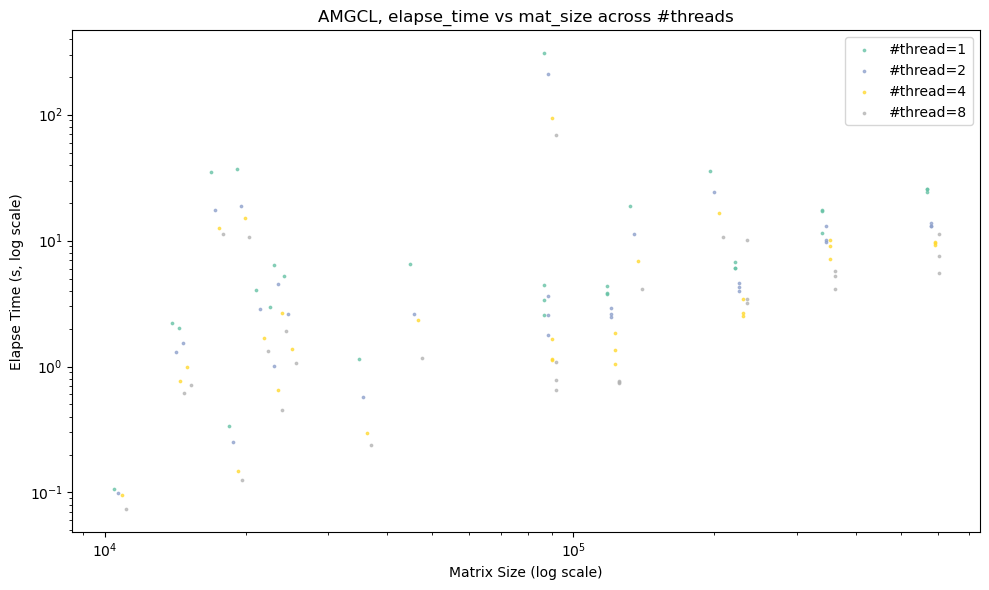

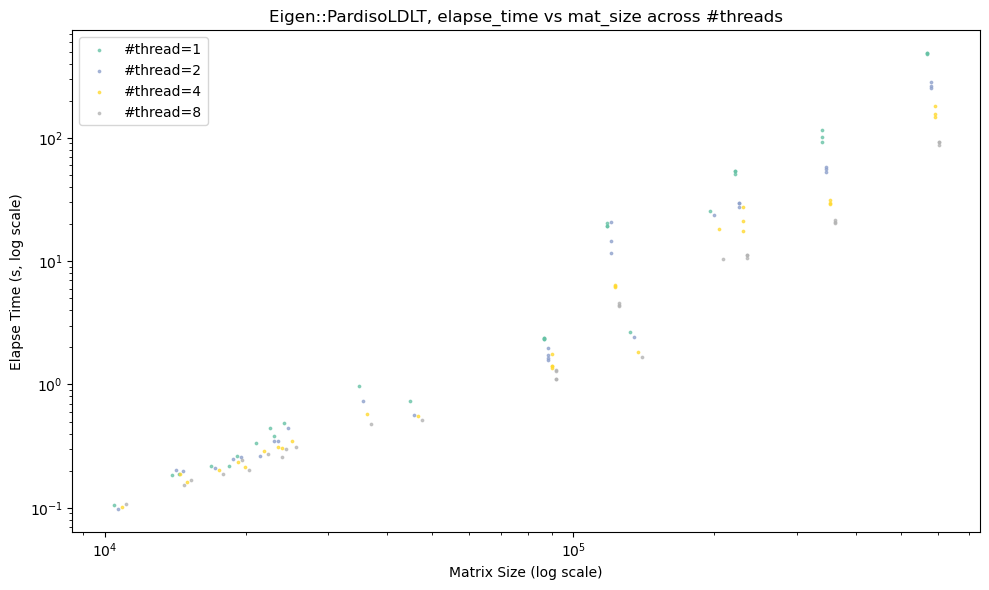

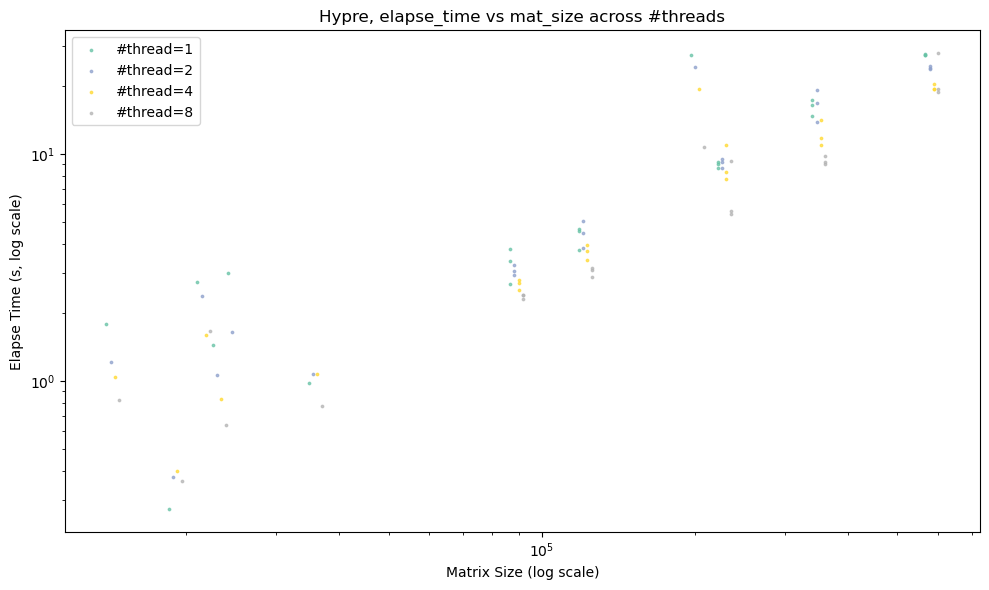

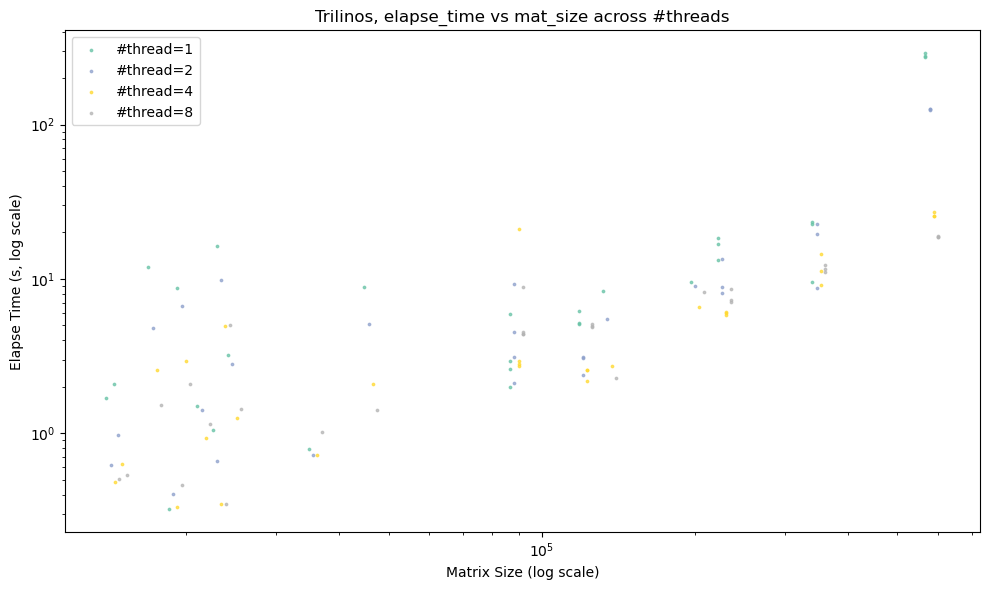

In [5]:
cmap_threads = cm.get_cmap("Set2", len(thread_values))

for solver in solver_list:
    df_s = df[(df["solver_name"] == solver) & (df["mat_sz"] >= 1e4)]
    if df_s.empty:
        continue

    plt.figure(figsize=(10, 6))
    offset = 1
    for idx, (nt, sdf) in enumerate(df_s.groupby("num_threads")):
        color = cmap_threads(idx)
        plt.scatter(sdf["mat_sz"] * offset, sdf["elapse_time"],
                    s=3, alpha=0.7, color=color, label=f"#thread={nt}")
        offset *= 1.02

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Matrix Size (log scale)")
    plt.ylabel("Elapse Time (s, log scale)")
    plt.title(f"{solver}, elapse_time vs mat_size across #threads")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Plot 3: All solvers compared at each #thread (mat_sz > 5e4, with trend lines)
Same as Plot 1 but filtered to larger matrices and with polynomial fit in log-log space.

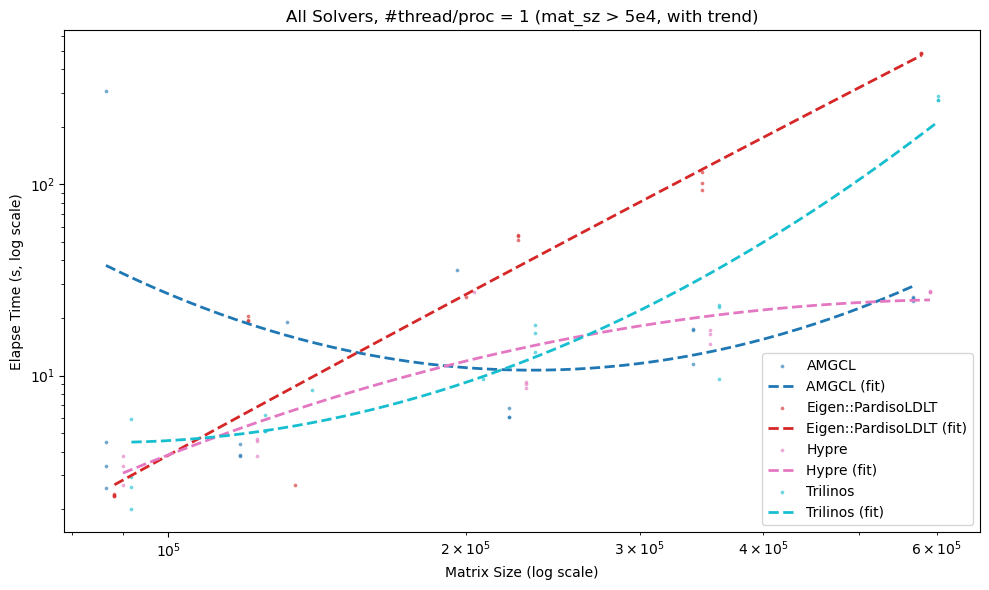

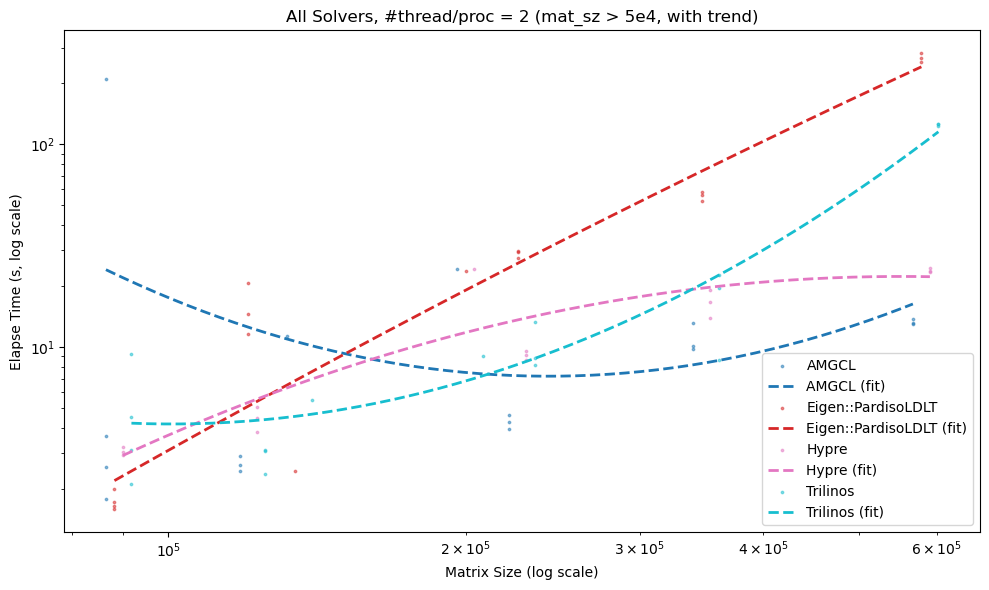

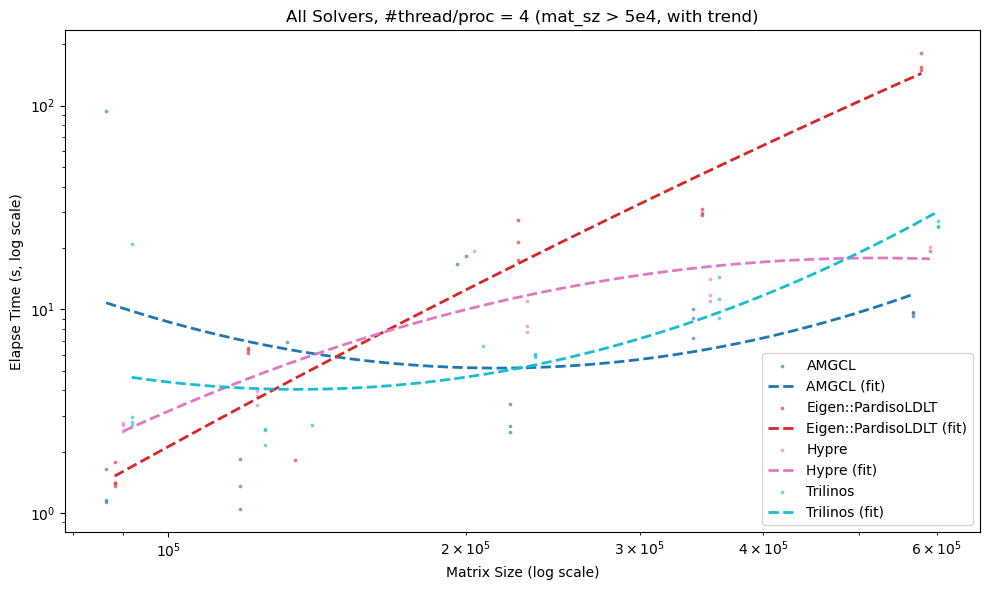

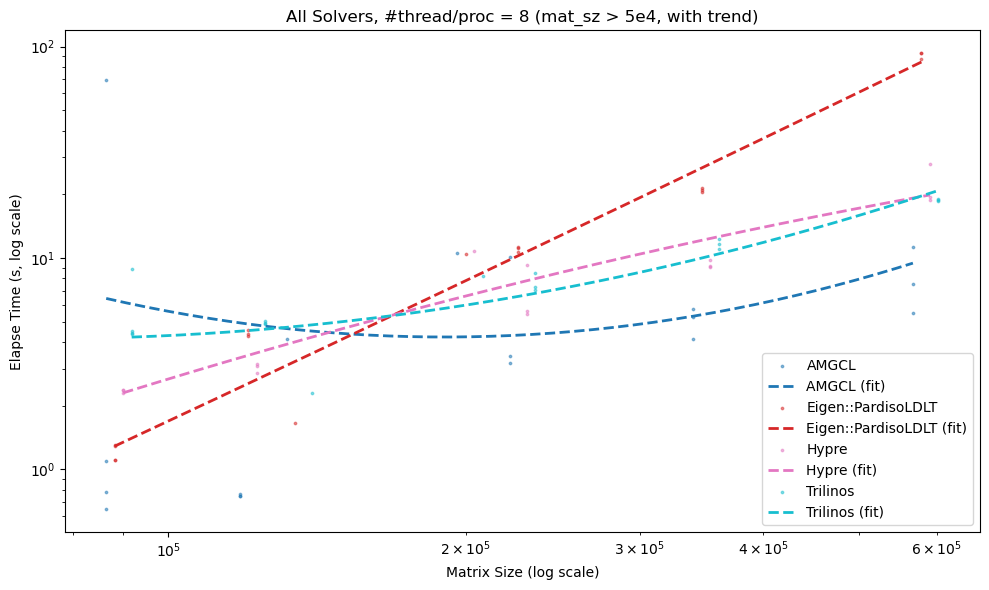

In [6]:
for nt in thread_values:
    df_t = df[(df["num_threads"] == nt) & (df["mat_sz"] > 5e4)]
    if df_t.empty:
        continue

    plt.figure(figsize=(10, 6))
    offset = 1
    for idx, (solver, sdf) in enumerate(df_t.groupby("solver_name")):
        color = cmap_solvers(idx)
        plt.scatter(sdf["mat_sz"] * offset, sdf["elapse_time"],
                    s=3, alpha=0.5, color=color, label=solver)

        # Fit trend curve in log-log space (degree-2 polynomial)
        g = sdf.groupby("mat_sz")["elapse_time"].mean().reset_index().sort_values("mat_sz")
        if len(g) >= 3:
            log_x = np.log10(g["mat_sz"].values)
            log_y = np.log10(g["elapse_time"].values)
            coeffs = np.polyfit(log_x, log_y, deg=2)
            x_fit = np.linspace(log_x.min(), log_x.max(), 200)
            y_fit = np.polyval(coeffs, x_fit)
            plt.plot(10**x_fit * offset, 10**y_fit,
                     color=color, linewidth=2, linestyle="--",
                     label=f"{solver} (fit)")
        offset *= 1.02

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Matrix Size (log scale)")
    plt.ylabel("Elapse Time (s, log scale)")
    plt.title(f"All Solvers, #thread/proc = {nt} (mat_sz > 5e4, with trend)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Plot 4: Each solver across different #threads (mat_sz > 5e4, with trend lines)
Same as Plot 2 but filtered to larger matrices and with polynomial fit in log-log space.

/tmp/ipykernel_2585438/2595774618.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_threads2 = cm.get_cmap("Set2", len(thread_values))


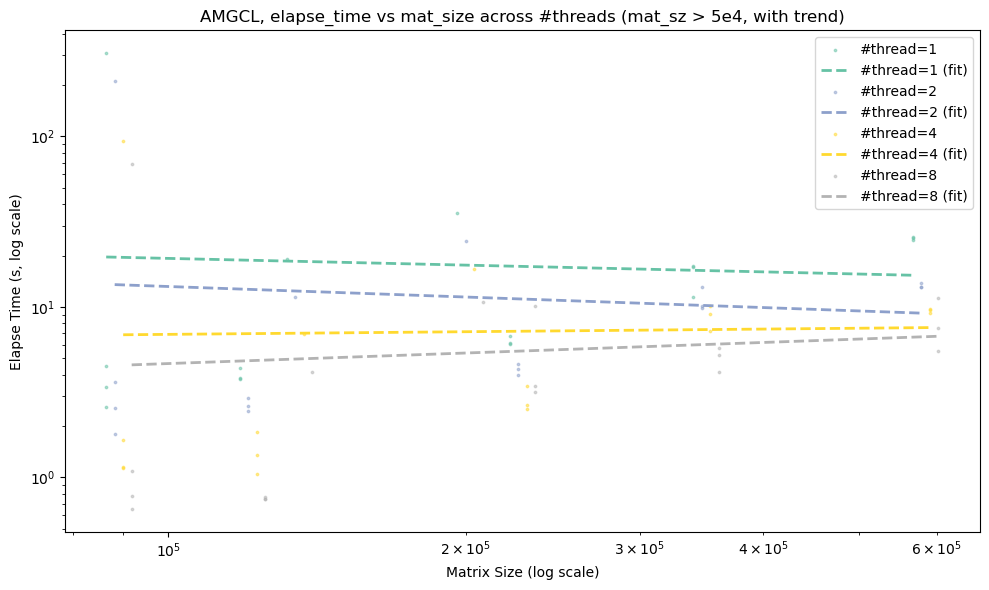

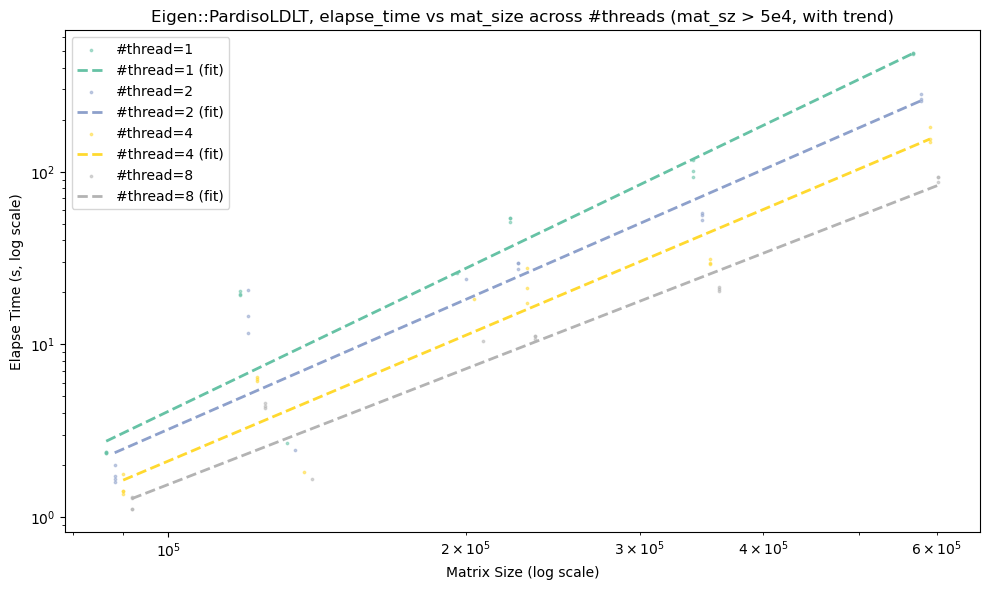

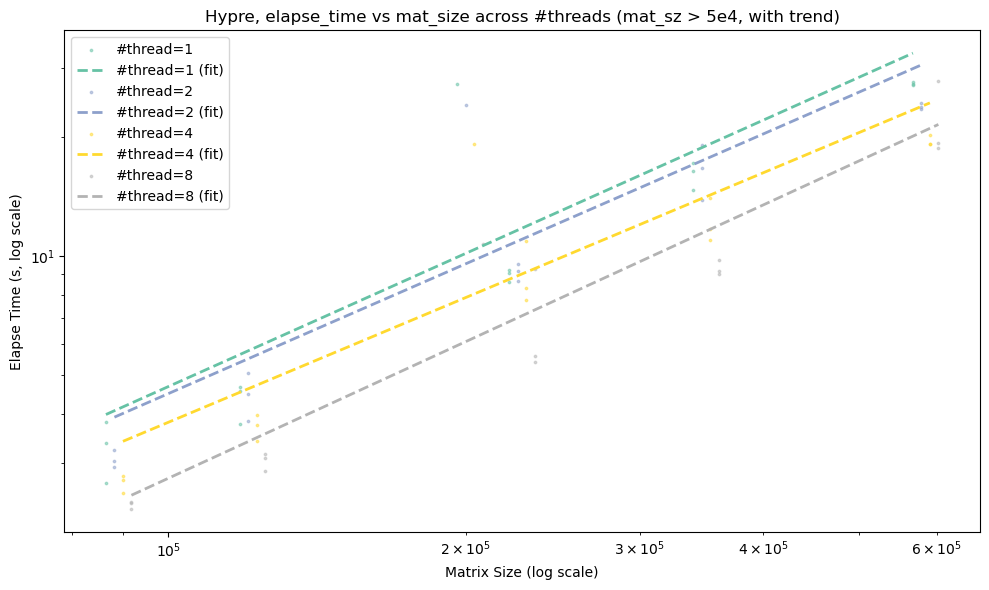

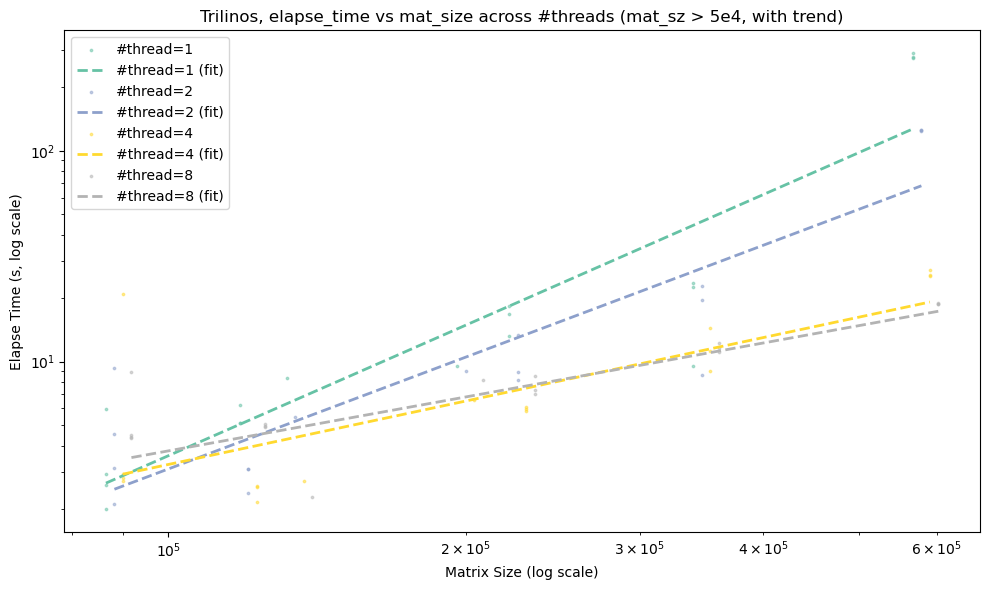

In [7]:
cmap_threads2 = cm.get_cmap("Set2", len(thread_values))

for solver in solver_list:
    df_s = df[(df["solver_name"] == solver) & (df["mat_sz"] > 5e4)]
    if df_s.empty:
        continue

    plt.figure(figsize=(10, 6))
    offset = 1
    for idx, (nt, sdf) in enumerate(df_s.groupby("num_threads")):
        color = cmap_threads2(idx)
        plt.scatter(sdf["mat_sz"] * offset, sdf["elapse_time"],
                    s=3, alpha=0.5, color=color, label=f"#thread={nt}")

        # Fit trend curve in log-log space (degree-2 polynomial)
        g = sdf.groupby("mat_sz")["elapse_time"].mean().reset_index().sort_values("mat_sz")
        if len(g) >= 3:
            log_x = np.log10(g["mat_sz"].values)
            log_y = np.log10(g["elapse_time"].values)
            coeffs = np.polyfit(log_x, log_y, deg=1)
            x_fit = np.linspace(log_x.min(), log_x.max(), 200)
            y_fit = np.polyval(coeffs, x_fit)
            plt.plot(10**x_fit * offset, 10**y_fit,
                     color=color, linewidth=2, linestyle="--",
                     label=f"#thread={nt} (fit)")
        offset *= 1.02

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Matrix Size (log scale)")
    plt.ylabel("Elapse Time (s, log scale)")
    plt.title(f"{solver}, elapse_time vs mat_size across #threads (mat_sz > 5e4, with trend)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Why Trilinos multi-process does not help on small matrices

From the plots above, Trilinos with more MPI processes (np=2, 4, 8) is often **slower** than np=1 on small matrices. This is expected for MPI-based distributed solvers and has several causes:

### 1. MPI communication overhead dominates computation

For a small matrix (e.g., mat_sz < 5e4), the actual computation per rank is tiny (microseconds), but each MPI collective operation (`MPI_Allreduce`, `MPI_Send`/`MPI_Recv`) has a fixed latency cost (~1-10 microseconds per call). GMRES performs multiple collectives per iteration (dot products, norms), and MueLu's AMG hierarchy adds multi-level communication. When the matrix is small, this fixed communication cost exceeds the computation saved by distributing the work.

### 2. MueLu AMG setup gets worse with more ranks

MueLu's `UncoupledAggregation` quality degrades with more processes: each rank aggregates independently, creating fragmented aggregates at process boundaries. More ranks = more boundaries = worse coarse grid = more GMRES iterations needed. We observed this directly: on the 339,975-DOF test matrix, np=2 needed 24 iterations while np=4 needed 56 (2.3x more).

For small matrices this effect is even more pronounced — with np=8 on a 1000-row matrix, each rank only has ~125 rows, which is too few for meaningful aggregation. The AMG hierarchy becomes essentially useless.

### 3. Redundant data: every rank holds the full matrix

In the current implementation, every MPI rank reads and holds the full matrix in memory, then each rank only fills its local rows into the distributed Tpetra matrix. For small matrices this means the data distribution overhead (Export/Import operations, map creation) is comparable to or larger than the actual solve time.

### 4. Process startup and Tpetra/Kokkos initialization

`mpirun` has a fixed startup cost to launch processes and initialize the MPI runtime. Tpetra and Kokkos initialization (device detection, memory pool setup) also runs on every rank. For small problems that solve in milliseconds, this startup cost alone can dominate.

### Takeaway

MPI parallelism only pays off when the matrix is large enough that the computation-per-rank significantly exceeds the communication overhead. For the problems tested here, this crossover point appears to be around **mat_sz > 1e5**. Below that threshold, single-process execution (or shared-memory parallelism like OpenMP) is more efficient.